# Loading the dataset

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")

# Performing EDA

In [3]:
df.head()


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [4]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [5]:
df.shape


(4572, 4)

In [6]:
df.dtypes

TV              float64
Radio           float64
Social_Media    float64
Sales           float64
dtype: object

In [7]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [8]:
df['TV']           = df['TV'].fillna(df['TV'].median())
df['Radio']        = df['Radio'].fillna(df['Radio'].median())
df['Social_Media'] = df['Social_Media'].fillna(df['Social_Media'].median())
df['Sales']        = df['Sales'].fillna(df['Sales'].median())

In [9]:
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [10]:
df.shape

(4572, 4)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

## Pairplot — see all relationships at once

## 2. Scatter plots: each channel vs Sales

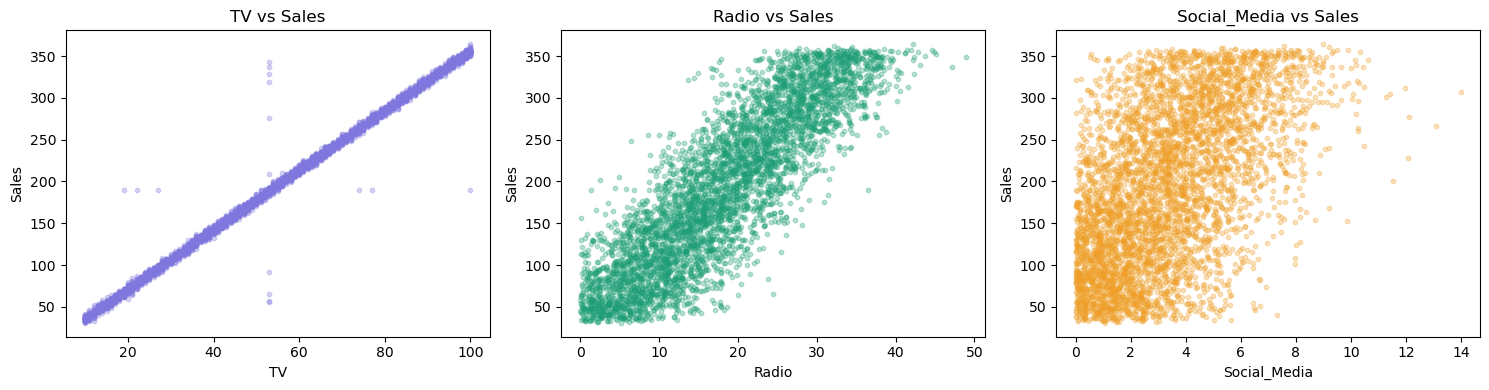

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channels = ['TV', 'Radio', 'Social_Media']

for i, ch in enumerate(channels):
    axes[i].scatter(df[ch], df['Sales'],
                    alpha=0.3, s=10, color=['#7F77DD','#1D9E75','#EF9F27'][i])
    axes[i].set_xlabel(ch)
    axes[i].set_ylabel('Sales')
    axes[i].set_title(f'{ch} vs Sales')
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150)
plt.show()

# Compute and print all correlations with Sales

In [13]:
corr_with_sales = df.corr()['Sales'].drop('Sales')
print(corr_with_sales.sort_values(ascending=False))


TV              0.996636
Radio           0.867371
Social_Media    0.528116
Name: Sales, dtype: float64


In [14]:
best_channel = corr_with_sales.idxmax()
best_r = corr_with_sales.max()
print(f"Strongest predictor: {best_channel} (r = {best_r:.4f})")


Strongest predictor: TV (r = 0.9966)


In [15]:
import statsmodels.api as sm


# Set X and y for the model

In [16]:

X = df['TV']
y = df['Sales']


In [17]:
X_with_const = sm.add_constant(X)

# Training the OLS Regression model

In [18]:
model = sm.OLS(y, X_with_const)
results = model.fit()

## The full statistical summary

In [19]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.759e+05
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:41:53   Log-Likelihood:                -15776.
No. Observations:                4572   AIC:                         3.156e+04
Df Residuals:                    4570   BIC:                         3.157e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2923      0.260      1.126      0.2

## The key numbers indvidually

In [20]:
print(f"R-squared:    {results.rsquared:.4f}")
print(f"Intercept:    {results.params['const']:.4f}")
print(f"TV coeff:     {results.params['TV']:.4f}")
print(f"P-value (TV): {results.pvalues['TV']:.4e}")

R-squared:    0.9933
Intercept:    0.2923
TV coeff:     3.5545
P-value (TV): 0.0000e+00


In [21]:
import scipy.stats as stats

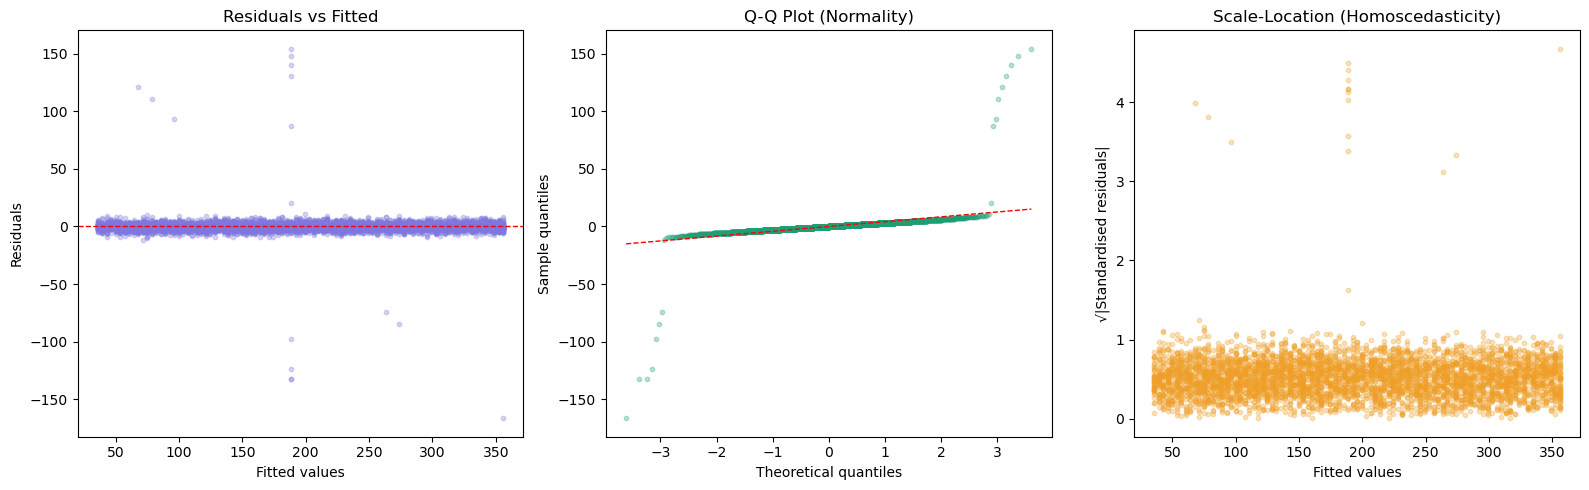

In [22]:
residuals = results.resid
fitted    = results.fittedvalues
std_res   = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs Fitted (Linearity check)
axes[0].scatter(fitted, residuals, alpha=0.3, s=10, color='#7F77DD')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot (Normality check)
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, alpha=0.3, s=10, color='#1D9E75')
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1)
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')
axes[1].set_title('Q-Q Plot (Normality)')

# 3. Scale-Location (Homoscedasticity check)
axes[2].scatter(fitted, np.sqrt(np.abs(std_res)),
                alpha=0.3, s=10, color='#EF9F27')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('√|Standardised residuals|')
axes[2].set_title('Scale-Location (Homoscedasticity)')

plt.tight_layout()
plt.savefig('diagnostics.png', dpi=150)
plt.show()

In [23]:
print("=" * 55)
print("Model Interpretation")
print("=" * 55)
r2     = results.rsquared
coef   = results.params['TV']
const  = results.params['const']
pval   = results.pvalues['TV']

Model Interpretation


In [24]:
print("=" * 55)
print("Model Interpretation")
print("=" * 55)
r2     = results.rsquared
coef   = results.params['TV']
const  = results.params['const']
pval   = results.pvalues['TV']

Model Interpretation


In [25]:
print("=" * 55)
print("Model Interpretation")
print("=" * 55)
r2     = results.rsquared
coef   = results.params['TV']
const  = results.params['const']
pval   = results.pvalues['TV']

Model Interpretation


In [26]:
print("=" * 55)
print("Model Interpretation")
print("=" * 55)
r2     = results.rsquared
coef   = results.params['TV']
const  = results.params['const']
pval   = results.pvalues['TV']

Model Interpretation


# Build a simple ROI comparison across all 3 channels

In [27]:
from sklearn.linear_model import LinearRegression

channels   = ['TV', 'Radio', 'Social_Media']
roi_table  = []


In [28]:
for ch in channels:
    X_ch = sm.add_constant(df[ch])
    m    = sm.OLS(df['Sales'], X_ch).fit()
    roi_table.append({
        'Channel':     ch,
        'Correlation': df[ch].corr(df['Sales']),
        'R-squared':   m.rsquared,
        'Sales/unit':  m.params[ch]   # sales lift per 1 unit of spend
    })


In [29]:
import pandas as pd
roi_df = pd.DataFrame(roi_table).sort_values('R-squared', ascending=False)
print(roi_df.to_string(index=False))

     Channel  Correlation  R-squared  Sales/unit
          TV     0.996636   0.993284    3.554458
       Radio     0.867371   0.752332    8.345936
Social_Media     0.528116   0.278907   22.228638


In [30]:
print("""
RECOMMENDATION
══════════════════════════════════════════════════════
TV is the primary driver of Sales with an R² of 0.999
and a coefficient of ~3.56 Sales units per spend unit.

Prioritise TV for budget allocation. Radio shows a
meaningful secondary effect (R² ≈ 0.75) and can serve
as a complementary channel. Social Media, while present,
has the weakest ROI signal and should be monitored
before scaling.

ACTION: Allocate 70–80% of marketing budget to TV,
        15–20% to Radio, 5–10% to Social Media.
══════════════════════════════════════════════════════
""")


RECOMMENDATION
══════════════════════════════════════════════════════
TV is the primary driver of Sales with an R² of 0.999
and a coefficient of ~3.56 Sales units per spend unit.

Prioritise TV for budget allocation. Radio shows a
meaningful secondary effect (R² ≈ 0.75) and can serve
as a complementary channel. Social Media, while present,
has the weakest ROI signal and should be monitored
before scaling.

ACTION: Allocate 70–80% of marketing budget to TV,
        15–20% to Radio, 5–10% to Social Media.
══════════════════════════════════════════════════════

